### 1. Импорты

In [25]:
import csv
import matplotlib.pyplot as plt
from pathlib import Path

### 2. Загрузка данных

5.346583494307
0.6033333333333334
0.39666666666666667
0.39431983870392845
0.37835339696908743
1.1510266326421033
0.6022860728015621
0.5487405598405412
0
0
0.21528264430317182
0.21528264430317182
1.1510266326421033
6.231244
0.706000
0.294000
0.287202
0.580583
1.448367
0.286673
0.264960
0.307061
0.049278
0.232436
0.281714
1.755428
7.077573574089064
0.7168141592920354
0.25663716814159293
0.224954333283238
0.675700674593428
1.576355682470094
0.1982405885057642
0.22540372902414174
0.6290888528941371
0.08888481996107055
0.2227254391591376
0.3116102591202081
2.205444535364231


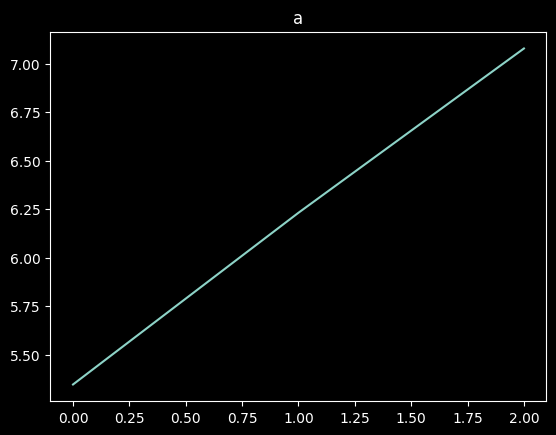

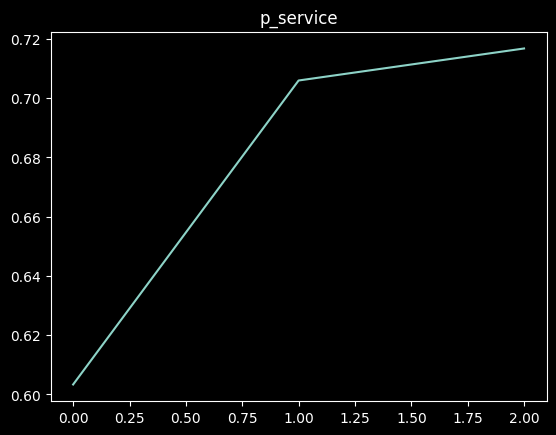

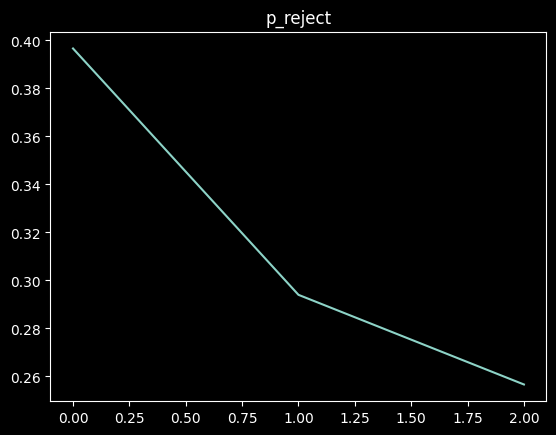

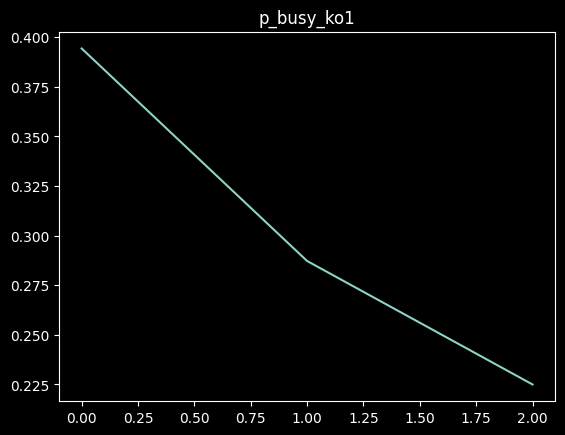

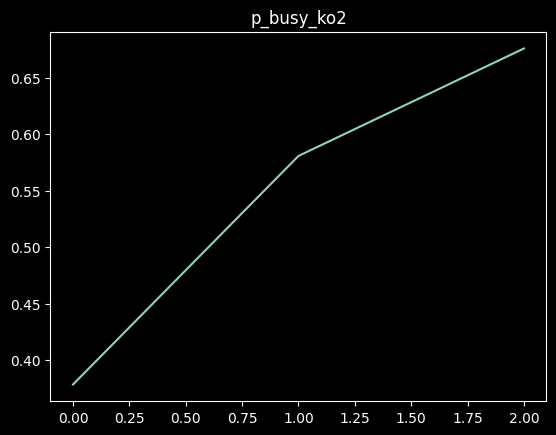

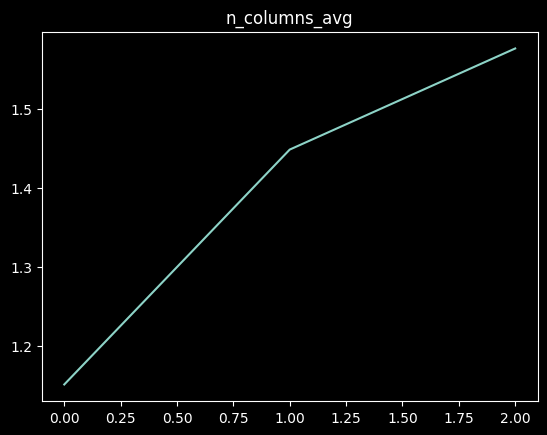

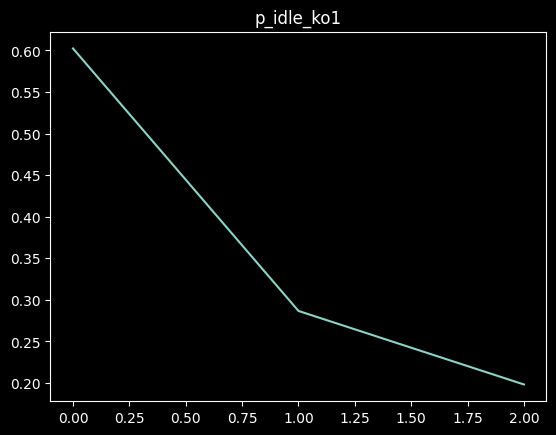

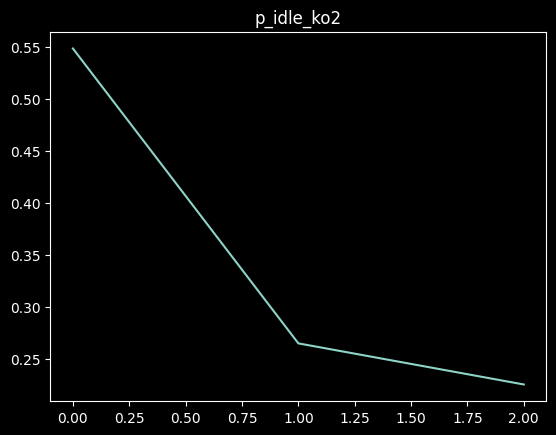

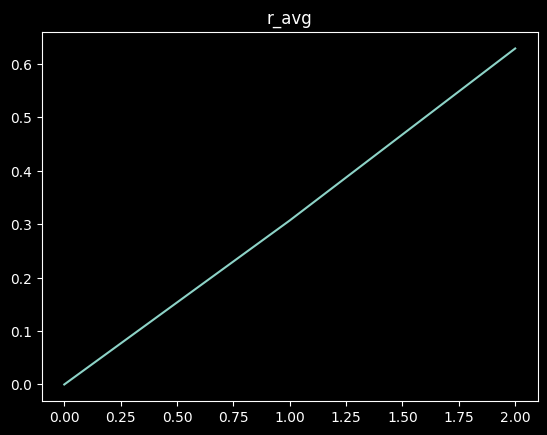

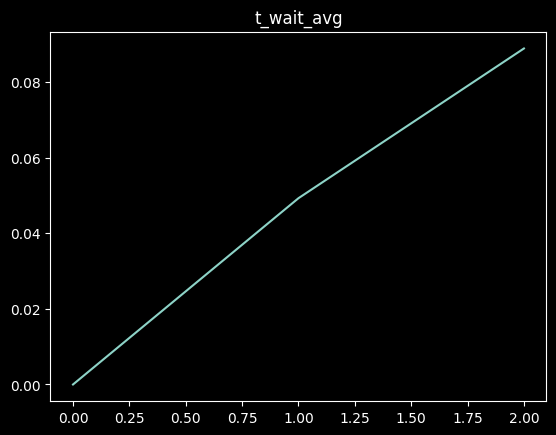

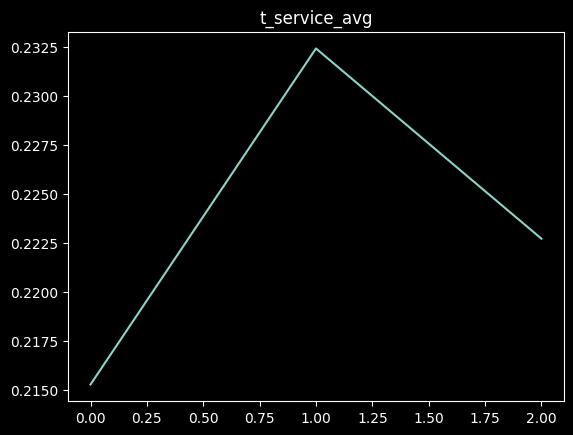

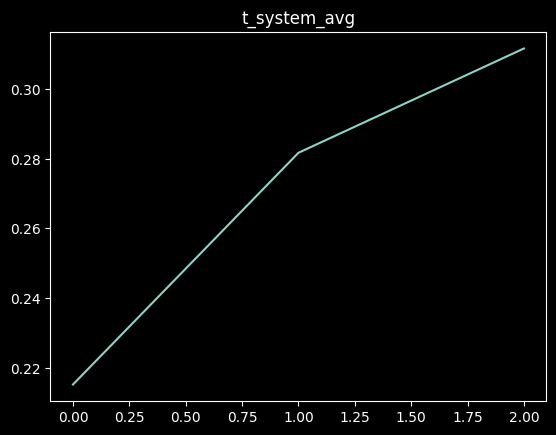

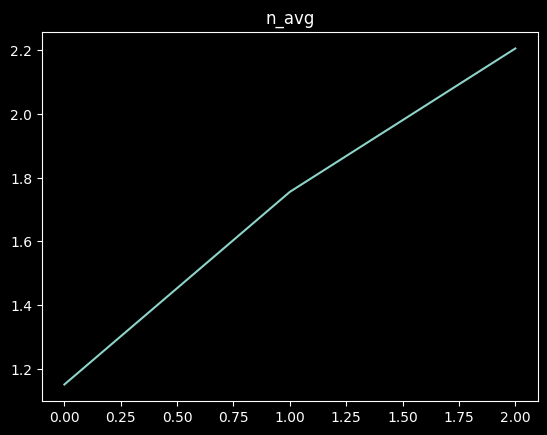

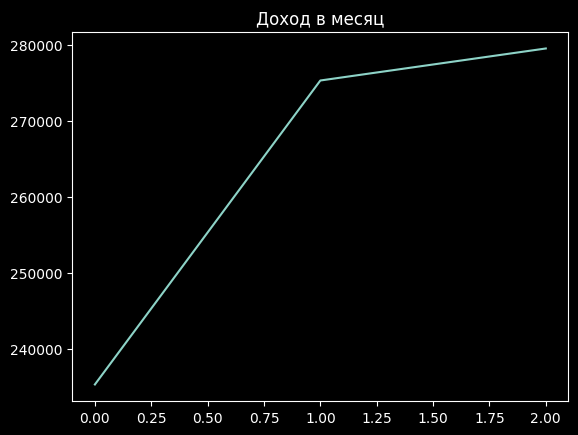

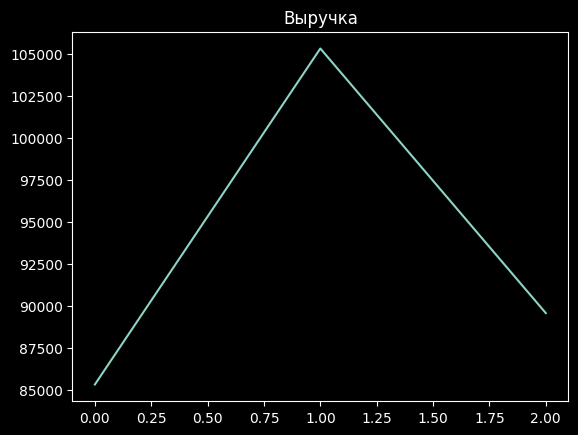

In [26]:
FILENAME = "results.csv"
BASE_DIR = Path.cwd()

def get_data_csv(path):
    if not path.exists():
        print("Файл не найден")
        return {}
    try:
        with open(path, "r", newline="") as file:
            reader = csv.reader(file)
            return {row[0]: row[1] for row in reader}

    except Exception as e:
        print(f"Ошибка работы с файлом {path}. {e}")
        return {}
data = {}
for i in range(3):
    path = BASE_DIR / f'{i}_queue_of_car' / FILENAME
    data_queue = get_data_csv(path)
    for key, value in data_queue.items():
        print(value)
        value = float(value)
        data[key] = [value] if key not in data else data[key] + [value]

rent_place = 20000
data["Доход в месяц"] = [i*1000*390 for i in data["p_service"]]
expenses = 150000
data["Выручка"] = [-rent_place*i - expenses  + data["Доход в месяц"][i] for i in range(3)]

for key, value in data.items():
    plt.title(key)
    plt.plot(value, label=key)
    plt.show()



Режим работы каждый день с 9 до 22 часов. 13 часов в день.
В месяц получается 13*30=390 часов. Предположим средний чек с автомобиля = 1000 руб.
Тогда домножив его на пропускную способность получим средний доход заправки в месяц.
Предположим аренда одного места в очереди нам обойдется в 20 тыс. руб.
Средние расходы заправки в месяц = 150 тыс. руб.